**Tareas a realizar**

**Análisis Exploratorio de Datos (EDA)**

- Generar histogramas de Edad e Ingresos.

- Calcular la correlación entre Edad, Ingresos y Experiencia.

- Visualizar relaciones con diagramas de dispersión.

**Aplicación de PCA para Reducción de Dimensionalidad**

- Normalizar los datos antes de aplicar PCA.

- Calcular cuántas componentes principales explican el 90% de la varianza.

- Visualizar los datos en 2D usando las dos primeras componentes principales.

**Segmentación de Clientes con Clustering**

- Aplicar K-Means Clustering con 3 clusters sobre los datos originales y luego sobre los datos transformados por PCA.

- Comparar los resultados y analizar si el agrupamiento cambia después de la reducción de dimensionalidad.

- Visualizar los clusters con gráficos de dispersión en 2D.

**Interacción con una Herramienta de IA (LLM)**

- Hacer una consulta a ChatGPT, Gemini u otra herramienta LLM para obtener insights sobre los clusters.

- Ejemplo de consulta: "Tengo datos de clientes con variables de edad, ingresos y experiencia. ¿Qué técnicas avanzadas puedo usar para mejorar la segmentación?"

- Comparar la respuesta con lo aprendido en la clase y reflexionar sobre su utilidad.


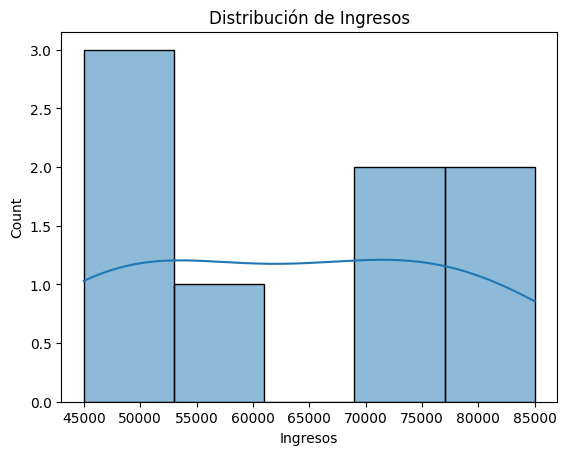

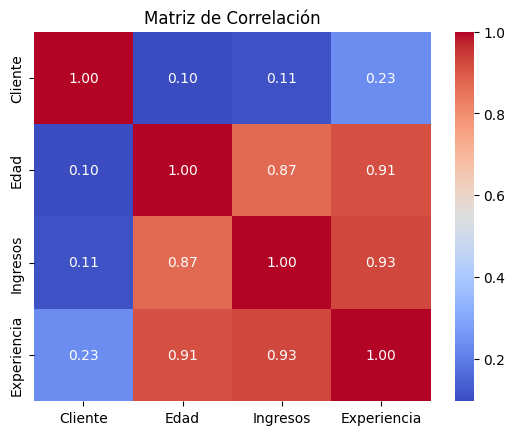

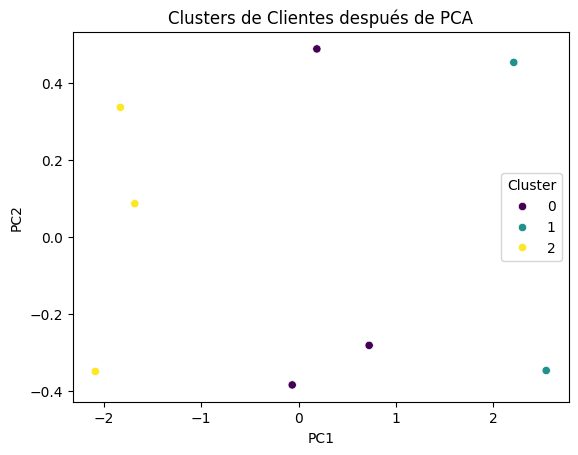

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Crear DataFrame
df = pd.DataFrame({
    "Cliente":     [1, 2, 3, 4, 5, 6, 7, 8],
    "Edad":        [25, 40, 35, 50, 30, 45, 38, 29],
    "Ingresos":    [50000, 60000, 70000, 80000, 45000, 85000, 72000, 48000],
    "Experiencia": [2, 10, 7, 15, 3, 20, 12, 4]
})

# 1) Análisis Exploratorio
sns.histplot(df["Ingresos"], bins=5, kde=True)
plt.title("Distribución de Ingresos")
plt.show()

# Matriz de correlación
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

# 2) Aplicar PCA
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[["Edad", "Ingresos", "Experiencia"]])
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=["PC1", "PC2"])

# 3) Aplicar Clustering K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df_pca["Cluster"] = kmeans.fit_predict(df_pca)

# Visualizar Clustering
sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"], hue=df_pca["Cluster"], palette="viridis")
plt.title("Clusters de Clientes después de PCA")
plt.show()

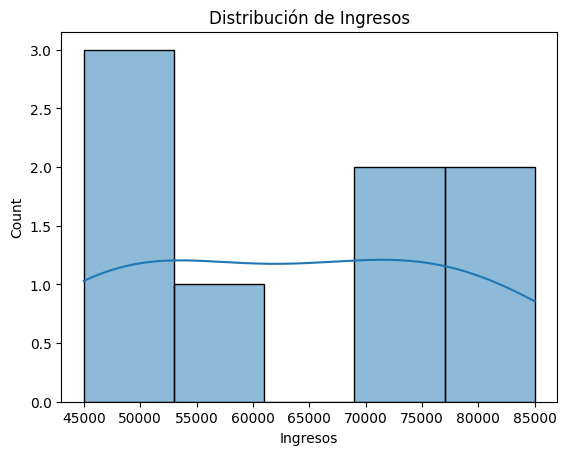

None




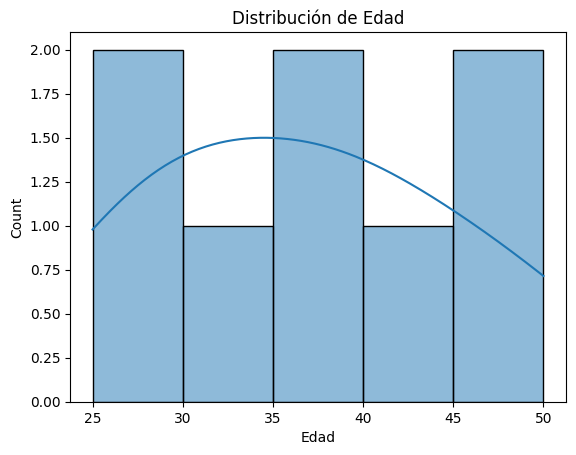

In [ ]:
# 1 - Histograma de Edad e Ingreso

sns.histplot(df["Ingresos"], bins=5, kde=True)
plt.title("Distribución de Ingresos")
print(plt.show())

sns.histplot(df["Edad"], bins=5, kde=True)
plt.title("Distribución de Edad")
print("\n") #Bajo un renglon
plt.show()

En cuanto a los histogramas podemos observar una distribución normal en las edades, no hay valor que destaque, pero podemos decir que el registro de menor valor es de 25, mientras que el mayor registrado es de 50.
También observamos que en el histograma de de ingresos encontramos que hay mayor cantidad de registros de personas con un ingreso bajo.

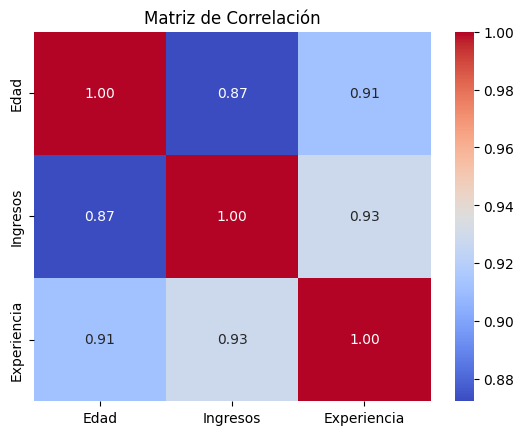

In [ ]:
# 2 - Matriz de Correlación entre Edad, Ingresos y Experiencia.

# Matriz de correlación
col1 = ["Edad", "Ingresos", "Experiencia"]
columnas_matriz = df.corr().loc[col1, col1]

sns.heatmap(columnas_matriz, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

En la Correlación entre las variables Edad, Ingresos y Experiencia, podemos observar que los valores superan el 0.80, es decir que hay una alta correlación entre las variables.

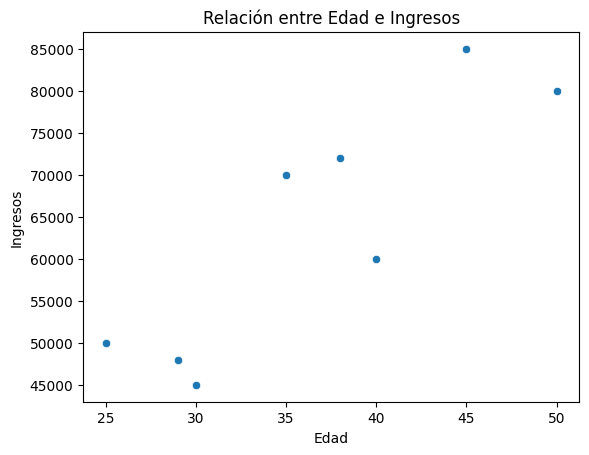

None




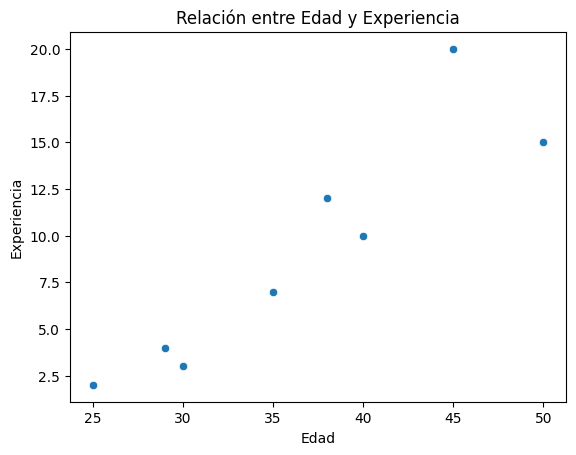

None




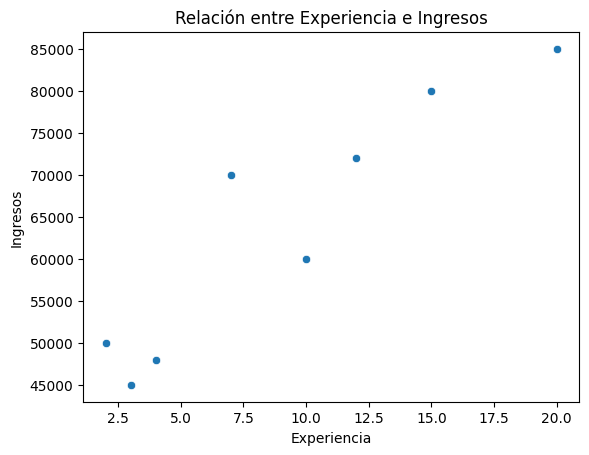

None


In [ ]:
# 3 - Diagramas de disperción

# x: Edad vs y: Ingresos
sns.scatterplot(x=df["Edad"], y=df["Ingresos"])
plt.title("Relación entre Edad e Ingresos")
print(plt.show())

# x: Edad vs y: Experiencia
sns.scatterplot(x=df["Edad"], y=df["Experiencia"])
plt.title("Relación entre Edad y Experiencia")
print("\n")
print(plt.show())

# x: Experiencia vs y: Ingresos
sns.scatterplot(x=df["Experiencia"], y=df["Ingresos"])
plt.title("Relación entre Experiencia e Ingresos")
print("\n")
print(plt.show())

Luego de Graficar la disperción observamos los 3 casos que son de correlaciones positivas, cuando un valor aumenta en una variable ocurre lo mismo con la otra, por ejemplo: según los datos estudiados, encontramos que si aumenta la edad, también aumentan la Experiencia y los Ingresos.

In [ ]:
# 4 - Normalizar los datos

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[["Edad", "Ingresos", "Experiencia"]])
print(df_scaled)

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=["PC1", "PC2"])
df_pca


[[-1.45174713 -0.96461543 -1.20246742]
 [ 0.44183608 -0.26307694  0.14767144]
 [-0.18935832  0.43846156 -0.35863063]
 [ 1.70422489  1.14000005  0.99150823]
 [-0.82055272 -1.31538468 -1.03370007]
 [ 1.07303049  1.4907693   1.83534501]
 [ 0.18935832  0.57876926  0.48520615]
 [-0.9467916  -1.10492313 -0.86493271]]


,PC1,PC2
0,-2.088358,-0.349258
1,0.187607,0.487469
2,-0.065374,-0.384217
3,2.210591,0.452509
4,-1.830565,0.335839
5,2.544210,-0.346833
6,0.724952,-0.281611
7,-1.683062,0.086102


Hago una Previsualización de las tablas con los datos normalizados y del PCA para luego estudiarlos y graficarlos.

[0.9362353  0.04299134]
PC1:  93.624 %
PC2:  4.299 %


PC1 + PC2:  97.923 %
Encontramos que el PC1 explica más del 90% de la varianza


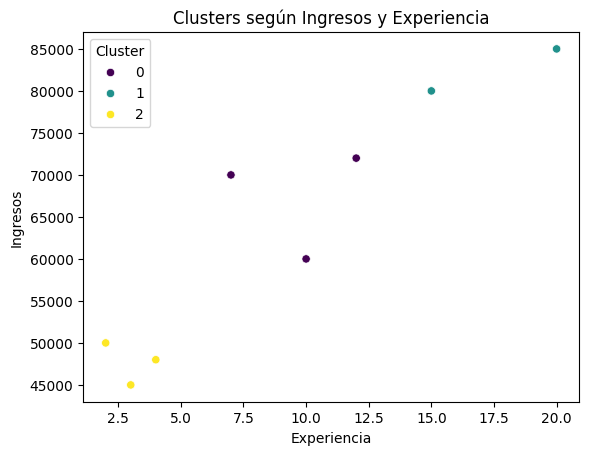

None


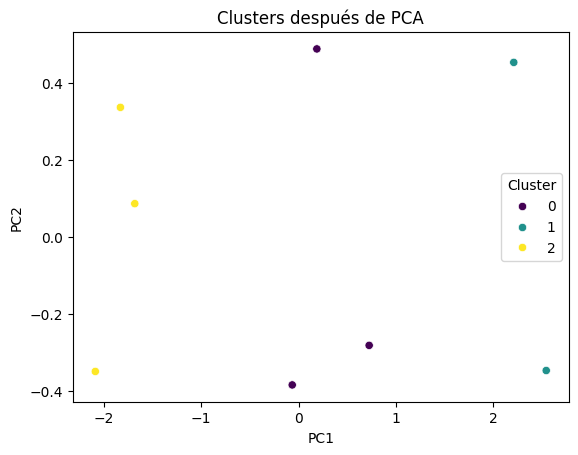

None


In [ ]:
# Calculo de Varianza Explicada y cantidad que explican el 90%
varianza = pca.explained_variance_ratio_
print(varianza)
print("PC1: ", round(varianza[0]*100,3),"%")
print("PC2: ", round(varianza[1]*100,3),"%")
print("\n")
print("PC1 + PC2: ", round(varianza[0]*100 + varianza[1]*100,3),"%")
print("Encontramos que el PC1 explica más del 90% de la varianza")
print("\n")

# Aplicar K-Means con 3 cluster
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(df_scaled)

# Visualizar clusters
sns.scatterplot(x=df["Experiencia"], y=df["Ingresos"], hue=df["Cluster"], palette="viridis")
plt.title("Clusters según Ingresos y Experiencia")
print(plt.show())

sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"], hue=df["Cluster"], palette="viridis")
plt.title("Clusters después de PCA")
print(plt.show())





Como podemos observar, el PC1 explica más del 90% de la varianza, mientras que el PC2 solo el 4%, también grafiqué 2 graficos de dispersión, en el primero para poder observar con datos normalizados, y luego con las variables del PCA. La conclusión en los datos normalizados se mantiene con el estudio de las variables, a su vez luego de aplicarle el clustering dividimos las posibilidades en 3; de esta información podemos deducir que:
- 2 = Personas con poca experiencia y pocos ingresos

- 0 = Personas con algo de experiencia y algo de ingresos

- 1 = Personas con mucha experiencia y muchos ingresos

En cuanto al gráfico de dispersión del PCA vemos que los datos están separados lo que indica que se encontró un patron, al igual que en el anterior gráfico vemos que los valores amarillos o "2" se encuentran en valores bajos, los violetas o "1" en el medio y los celestes o "0" del lado derecho o positivos.